# **Case Study : Analyzing Virat Kohli Batting Performance in IPL 2022**

### Problem Statement:


#### Comprehensive analysis on the batting performance of Virat Kohli in IPL 2022. Analyzing various aspects of his performance, such as runs scored, strike rate at different phases,boundaries hit (4s and 6s). Identify his strengths and weaknesses, and provide insights on his overall performance.

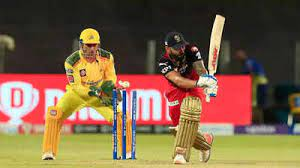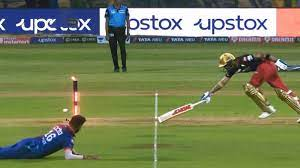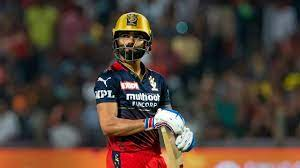

# Table of Contents
* [Data Collection](#dc)
* [Data Exploration](#de)
* [Data Cleaning](#dcng)
* [Data Analysis](#da)
    * [Total Runs scored by Virat Kohli](#tr)
    * [Number of Fours(4s)](#t4)
    * [Number of Sixes(6s)](#t6)
    * [Total Boundaries hit by Virat Kohli](#tb)
    * [Strike rate of Virat Kohli](#tsr)
    * [Number of 1s](#t1)
    * [Number of 2s](#t2)
    * [Number of 3s](#t3)
    * [Number of dot balls played by Virat Kohli](#tdot)
    * [Batting Average of Virat Kohli](#tba)
    * [Most common over at which Virat Kohli got out](#tco)
    * [Most kind of dismissal at which Virat Kohli got out](#tmk)
    * [Batting Performances at different phases](#tpf)

* [Conclusion](#con)

## Data Collection <a name="dc"></a>

### Dataset  - Virat Kohli Ball-by-Ball Data (IPL 2022)

This dataset contains ball-by-ball information related to Virat Kohli's performances during the Indian Premier League (IPL) in the year 2022. The dataset provides details about each delivery faced by Virat Kohli.

### Column Descriptions

1. `ID`: An identifier for each row.
2. `innings`: Indicates the innings number in which the delivery was played (1st or 2nd innings).
3. `overs`: Represents the over number in which the delivery was bowled.
4. `ballnumber`: The specific ball number of the over.
5. `batter`: Name of the batsman (Virat Kohli).
6. `bowler`: Name of the bowler who bowled the delivery.
7. `non-striker`: Name of the non-striker at the crease during the delivery.
8. `extra_type`: Type of extras scored in that delivery (wide, no-ball, etc.).
9. `batsman_run`: Number of runs scored by Virat Kohli on that delivery.
10. `extras_run`: Number of extra runs scored on that delivery.
11. `total_run`: Total runs scored on that delivery (including batsman runs and extras).
12. `non_boundary`: Indicates if the runs scored on the delivery were from non-boundary hits.
13. `isWicketDelivery`: A binary indicator (1 or 0) representing whether Virat Kohli got out on that delivery or not.
14. `player_out`: Name of the player who got out (if `isWicketDelivery` is 1).
15. `kind`: Type of dismissal (e.g., caught, bowled, run-out, etc.).
16. `fielders_involved`: Names of fielders involved in the dismissal.
17. `BattingTeam`: Name of the team for which Virat Kohli was batting.


## Data Exploration <a name="de"></a>

In [ ]:
import pandas as pd

In [ ]:
# Load the dataset 'virat_kohli_ball_by_ball_2022.csv'
data = pd.read_csv('/content/virat_kohli_ball_by_ball_2022.csv')

data.head()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
0,1304049,1,7,2,V Kohli,Harpreet Brar,F du Plessis,NaN,1,0,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore
1,1304049,1,7,4,V Kohli,Harpreet Brar,F du Plessis,NaN,0,0,0,0,0,NaN,NaN,NaN,Royal Challengers Bangalore
2,1304049,1,7,5,V Kohli,Harpreet Brar,F du Plessis,NaN,1,0,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore
3,1304049,1,8,1,V Kohli,RD Chahar,F du Plessis,NaN,1,0,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore
4,1304049,1,9,1,V Kohli,Harpreet Brar,F du Plessis,NaN,2,0,2,0,0,NaN,NaN,NaN,Royal Challengers Bangalore


In [ ]:
# Check the shape of the DataFrame 'data'
data.shape

(306, 17)

* The dataset 'data' contains a total of **306 rows** and **17 columns**

In [ ]:
# Get the column names of the DataFrame 'data'
data.columns

Index(['ID', 'innings', 'overs', 'ballnumber', 'batter', 'bowler',
       'non-striker', 'extra_type', 'batsman_run', 'extras_run', 'total_run',
       'non_boundary', 'isWicketDelivery', 'player_out', 'kind',
       'fielders_involved', 'BattingTeam'],
      dtype='object')

In [ ]:
# Get information about the DataFrame 'data'
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 306 non-null    int64 
 1   innings            306 non-null    int64 
 2   overs              306 non-null    int64 
 3   ballnumber         306 non-null    int64 
 4   batter             306 non-null    object
 5   bowler             306 non-null    object
 6   non-striker        306 non-null    object
 7   extra_type         14 non-null     object
 8   batsman_run        306 non-null    int64 
 9   extras_run         306 non-null    int64 
 10  total_run          306 non-null    int64 
 11  non_boundary       306 non-null    int64 
 12  isWicketDelivery   306 non-null    int64 
 13  player_out         16 non-null     object
 14  kind               16 non-null     object
 15  fielders_involved  13 non-null     object
 16  BattingTeam        306 non-null    object
dt

In [ ]:
data.describe()

,ID,innings,overs,ballnumber,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery
count,3.060000e+02,306.000000,306.00000,306.000000,306.000000,306.000000,306.000000,306.0,306.000000
mean,1.304986e+06,1.441176,6.46732,3.382353,1.114379,0.068627,1.183007,0.0,0.052288
std,2.554006e+03,0.497341,5.12025,1.744560,1.454216,0.411151,1.459566,0.0,0.222971
min,1.304049e+06,1.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,1.304064e+06,1.000000,2.00000,2.000000,0.000000,0.000000,0.000000,0.0,0.000000
50%,1.304089e+06,1.000000,6.00000,3.000000,1.000000,0.000000,1.000000,0.0,0.000000
75%,1.304113e+06,2.000000,10.00000,5.000000,1.000000,0.000000,1.000000,0.0,0.000000
max,1.312199e+06,2.000000,19.00000,7.000000,6.000000,5.000000,6.000000,0.0,1.000000


## Data Cleaning <a name="dcng"></a>

In [ ]:
duplicate = data[data.duplicated()]

print("Duplicate Rows :")

duplicate

Duplicate Rows :


,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam


In [ ]:
data.isna().sum()

ID                     0
innings                0
overs                  0
ballnumber             0
batter                 0
bowler                 0
non-striker            0
extra_type           292
batsman_run            0
extras_run             0
total_run              0
non_boundary           0
isWicketDelivery       0
player_out           290
kind                 290
fielders_involved    293
BattingTeam            0
dtype: int64

* Our dataset is clean without any duplicate records and null values. In case if our dataset have duplicate records we drop them and in case of null values we fill it using using `fillna()` depending on the data.
* **Note:** extra_type,player_out,kind,fielders_involved these will have null values because we will have these values only when bowler balls extras(wide,no-ball...), take wicket.  

## Data Analysis <a name="da"></a>

### Total runs scored by Virat Kohli in IPL 2022<a name="tr"></a>

In [ ]:
# Calculate the total runs scored by Virat Kohli in IPL 2022
total_runs = data['batsman_run'].sum()

print("Total Runs:",total_runs)

Total Runs: 341


* Virat Kohli scored a total of 341 runs in IPL 2022, which is the sum of the runs he scored in all the deliveries.

### Number of fours hit by Virat Kohli <a name="t4"></a>

In [ ]:
# Filter the data to include only the deliveries where Virat Kohli scored 4 runs
fours = data[data['batsman_run']==4]

print(f"Total number of fours:{len(fours)}")

Total number of fours:32


### Number of sixes hit by Virat Kohli <a name="t6"></a>

In [ ]:
# Filter the data to include only the deliveries where Virat Kohli scored 6 runs
sixes = data.query("batsman_run == 6")

print(f"Total number of sixes:{len(sixes)}")

Total number of sixes:8


### Total boundaries hit by Virat Kohli <a name="tb"></a>

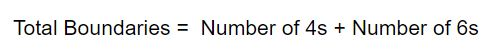

In [ ]:
#Calculate total boundaries by summing 4s and 6s
total_boundaries = len(sixes)+len(fours)

print(f"Total Boundaries:{total_boundaries}")

Total Boundaries:40


* Virat Kohli hit 40 boundaries in IPL 2022.

### Strike Rate of Virat Kohli in IPL 2022 <a name="tsr"></a>

To know total balls faced we use "ball_number" and "extras" columns.

In [ ]:
extras = data['extra_type'].value_counts()

extras

wides      12
legbyes     2
Name: extra_type, dtype: int64

In [ ]:
total_balls_faced = len(data['extra_type']) - (data['extra_type']=='wides').sum()

print("Total balls faced by virat kohli:",total_balls_faced)

Total balls faced by virat kohli: 294


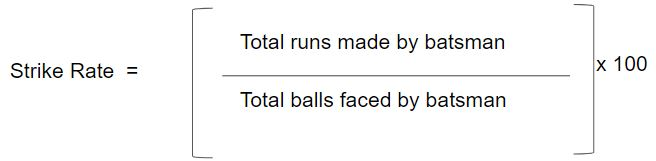

In [ ]:
total_runs = data['batsman_run'].sum()

strike_rate = (total_runs/total_balls_faced) * 100

print(f"Strike rate:{strike_rate:.2f}")

Strike rate:115.99


### Number of singles(1s) <a name="t1"></a>

In [ ]:
# Filter the data to include only the deliveries where Virat Kohli scored 1 run
singles = data[data['batsman_run']==1]

print(f"Total number of 1s:{len(singles)}")

Total number of 1s:117


### Number of doubles(2s) <a name="t2"></a>

In [ ]:
# Filter the data to include only the deliveries where Virat Kohli scored 2 runs
doubles = data[data['batsman_run']==2]

print(f"Total number of 2s:{len(doubles)}")

Total number of 2s:18


### Number of 3s <a name="t3"></a>

In [ ]:
# Filter the data to include only the deliveries where Virat Kohli scored 3 runs
triples = data.query("batsman_run == 3")

print(f"Total number of 3s:{len(triples)}")

Total number of 3s:4


### Number of dot balls Virat Kohli played <a name="tdot"></a>

In [ ]:
# Filter the data to include only the deliveries where Virat Kohli played dot balls
dots = data.query("batsman_run == 0")

print(f"Total number of dots:{len(dots)}")

Total number of dots:127


### Batting Average of Virat Kohli <a name="tba"></a>

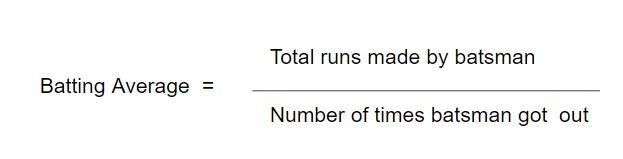

In [ ]:
# How many times Virat got out
times_out = data[data['player_out'] == 'V Kohli']['isWicketDelivery'].sum()

print("Number of times Virat Kohli got out:", times_out)

Number of times Virat Kohli got out: 14


In [ ]:
batting_avg = total_runs/times_out

print(f"Batting Average of Virat Kohli:{batting_avg:.2f}")

Batting Average of Virat Kohli:24.36


### Most common over Virat Kohli got out <a name="tco"></a>

In [ ]:
# Most of the time at which over he got out
most_common_over = data[data['player_out'] == 'V Kohli']['overs'].value_counts().idxmax()

print("Most common over at which Virat Kohli got out:", most_common_over)

Most common over at which Virat Kohli got out: 1


In [ ]:
# Most of the time at which over he got out
common_over = data[data['player_out'] == 'V Kohli']['overs'].value_counts()


percent_common_over = []
for i in common_over.values:
    percentage_over = (i/times_out)*100
    percent_common_over.append(percentage_over)

print(f"Virat Kohli got out {(percent_common_over[0]):.2f}% in {common_over.idxmax()} over.")


Virat Kohli got out 21.43% in 1 over.


### Which kind of dismissal Virat Kohli got out <a name="tmk"></a>

In [ ]:
#Which kind he was out most of the times
most_common_kind = data[data['player_out'] == 'V Kohli']['kind'].value_counts().idxmax()

print("Most common kind of dismissal for Virat Kohli:", most_common_kind)

Most common kind of dismissal for Virat Kohli: caught


In [ ]:
#Which kind he was out most of the times
common_kind = data[data['player_out'] == 'V Kohli']['kind'].value_counts()

percent_common_kind = []
for j in common_kind.values:
    percentage_kind = (j/times_out)*100
    percent_common_kind.append(percentage_kind)

print(f"Virat Kohli got out {percent_common_kind[0]:.2f}% by {common_kind.idxmax()} out.")

Virat Kohli got out 64.29% by caught out.


### Batting performance during powerplay, middle overs and death overs <a name="tpf"></a>

In [ ]:
# phases of the innings
powerplay_overs = range(0, 7)
middle_overs = range(7, 16)
death_overs = range(16, 21)

# Create a new column 'innings_phase' to identify the phase of each delivery
def categorize_innings_phase(overs):
    if overs in powerplay_overs:
        return 'Powerplay'
    elif overs in middle_overs:
        return 'Middle Overs'
    elif overs in death_overs:
        return 'Death Overs'
    else:
        return 'Other'

data['innings_phase'] = data['overs'].apply(categorize_innings_phase)

# Group the data by 'innings_phase'
phase_group = data.groupby('innings_phase')


# Calculate various batting performance metrics for each phase
phase_stats = phase_group.agg({
    'total_run': 'sum',
    'batsman_run': 'sum',
    'ballnumber': 'count'
})

# Calculate strike rate for each phase
phase_stats['strike_rate'] = (phase_stats['batsman_run'] / phase_stats['ballnumber']) * 100

# Display the results
phase_stats


,total_run,batsman_run,ballnumber,strike_rate
innings_phase,,,,
Death Overs,22,22,19,115.789474
Middle Overs,159,151,129,117.054264
Powerplay,181,168,158,106.329114


In [ ]:
#phases of the innings
powerplay_overs = range(0, 7)
middle_overs = range(7, 16)
death_overs = range(16, 21)

# Filter for powerplay, middle overs, and death overs
powerplay_df = data[data['overs'].isin(powerplay_overs)]
middleovers_df = data[data['overs'].isin(middle_overs)]
deathovers_df = data[data['overs'].isin(death_overs)]

# Calculate various batting performance metrics for each phase
powerplay_stats = powerplay_df.agg({
    'total_run': 'sum',
    'batsman_run': 'sum',
    'ballnumber': 'count'
})
powerplay_stats['strike_rate'] = (powerplay_stats['batsman_run'] / powerplay_stats['ballnumber']) * 100

middleovers_stats = middleovers_df.agg({
    'total_run': 'sum',
    'batsman_run': 'sum',
    'ballnumber': 'count'
})
middleovers_stats['strike_rate'] = (middleovers_stats['batsman_run'] / middleovers_stats['ballnumber']) * 100

deathovers_stats = deathovers_df.agg({
    'total_run': 'sum',
    'batsman_run': 'sum',
    'ballnumber': 'count'
})
deathovers_stats['strike_rate'] = (deathovers_stats['batsman_run'] / deathovers_stats['ballnumber']) * 100

# Statistics to DataFrame format and transpose
powerplay_stats_df = pd.DataFrame(powerplay_stats).T
powerplay_stats_df.columns = ['total_run', 'kohli_runs', 'balls_faced', 'strike_rate']

middleovers_stats_df = pd.DataFrame(middleovers_stats).T
middleovers_stats_df.columns = ['total_run', 'kohli_runs', 'balls_faced', 'strike_rate']

deathovers_stats_df = pd.DataFrame(deathovers_stats).T
deathovers_stats_df.columns = ['total_run', 'kohli_runs', 'balls_faced', 'strike_rate']

# Convert float columns to integers
powerplay_stats_df[['total_run', 'kohli_runs', 'balls_faced']] = powerplay_stats_df[['total_run', 'kohli_runs', 'balls_faced']].astype(int)
middleovers_stats_df[['total_run', 'kohli_runs', 'balls_faced']] = middleovers_stats_df[['total_run', 'kohli_runs', 'balls_faced']].astype(int)
deathovers_stats_df[['total_run', 'kohli_runs', 'balls_faced']] = deathovers_stats_df[['total_run', 'kohli_runs', 'balls_faced']].astype(int)

# Display the results
print("Powerplay Statistics:")
print(powerplay_stats_df)

print("\nMiddle Overs Statistics:")
print(middleovers_stats_df)

print("\nDeath Overs Statistics:")
print(deathovers_stats_df)


Powerplay Statistics:
   total_run  kohli_runs  balls_faced  strike_rate
0        181         168          158   106.329114

Middle Overs Statistics:
   total_run  kohli_runs  balls_faced  strike_rate
0        159         151          129   117.054264

Death Overs Statistics:
   total_run  kohli_runs  balls_faced  strike_rate
0         22          22           19   115.789474


## Conclusion - Analysis of Virat Kohli performance in IPL 2022  <a name="con"></a>

After analyzing the ball by ball data of Virat Kohli during IPL 2022 season. The following conclusions are made:

- **Total Runs**: Virat Kohli scored a total of 341(294) runs in IPL 2022.
- **Strike Rate**: Virat Kohli maintained strike rate of 117.59.
- **Batting Average**: Virat Kohli maintained batting average of 24.56 in IPL 2022.

* Virat Kohli had a slower strike rate during the powerplay overs, he was inconsistent in scoring runs throughout IPL 2022.<br>
* The most common dismissal method for him was being caught(64.29%), and he faced a higher risk of getting out in the 1st over(21.43%),  especially on the first ball.
* He managed to maintain a decent overall strike rate in  the  middle overs and contributed significantly with 40 boundaries to his total of 341 runs in IPL 2022.
* One major issue for Kohli is low powerplay strik rate. Instead of finding the right balance between singles and boundaries, Kohli settled for more singles(117).
* Overall, it was a challenging IPL season for Virat Kohli.

This notebook utilizes the pandas library for data analysis. The official documentation for pandas can be found at:
- [Pandas Documentation](https://pandas.pydata.org/docs/user_guide/index.html#user-guide)

The dataset used in this notebook is sourced from internet. It provides cricket statistics and information. You can access the dataset at:
- [Dataset](https://github.com/samar4saeedkhan/IPL-2022-Analysis/blob/main/DATA/IPL_Ball_by_Ball_2022.csv)

Image sources:
- [Image 1](https://www.google.com/url?sa=i&url=https%3A%2F%2Ftimesofindia.indiatimes.com%2Fsports%2Fcricket%2Fipl%2Ftop-stories%2Fipl-2022-mental-exhaustion-affecting-virat-kohli-accepting-current-phase-with-brutal-honesty-might-help-him-says-sports-psychologist-dr-priyanka-sarkar%2Farticleshow%2F91617252.cms&psig=AOvVaw2r8snleF77Yors-1FbLe7w&ust=1690364178845000&source=images&cd=vfe&opi=89978449&ved=2ahUKEwjwztG0x6mAAxVKm2MGHccBA4kQr4kDegUIARCdAQ)
- [Image 2](https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.hindustantimes.com%2Fcricket%2Fvirat-kohli-falls-agonisingly-short-registers-unwanted-ipl-dismissal-record-after-a-nine-year-gap-101650121537178.html&psig=AOvVaw0zHdrK_rjwgFrjo42s91o9&ust=1690364251653000&source=images&cd=vfe&opi=89978449&ved=2ahUKEwjIxq3Xx6mAAxXUmmMGHbBtBOcQr4kDegUIARDeAQ)
- [Image 3](https://www.google.com/url?sa=i&url=https%3A%2F%2Ftimesofindia.indiatimes.com%2Fsports%2Fcricket%2Fipl%2Ftop-stories%2Fipl-2022-concerned-that-different-types-of-bowlers-are-getting-virat-kohli-out-says-ian-bishop%2Farticleshow%2F91339621.cms&psig=AOvVaw0IarfWIa3c0lyjp1GLtYHF&ust=1690364310868000&source=images&cd=vfe&opi=89978449&ved=2ahUKEwiW4svzx6mAAxVjoekKHTUmDbAQr4kDegUIARDRAQ)